In [1]:
# ================================
# Step 1: Import Libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [3]:
# ================================
# Step 2: Load Dataset
# ================================
df = pd.read_csv(r"D:\Gradtwin\Stock Price Prediction\Oil_Data_Cleaned.csv")

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Set Date as index
df.set_index("Date", inplace=True)

print(df.head())

                           Adj_Close      Close       High        Low  \
Date                                                                    
2000-08-23 00:00:00+00:00  32.049999  32.049999  32.799999  31.950001   
2000-08-24 00:00:00+00:00  31.629999  31.629999  32.240002  31.400000   
2000-08-25 00:00:00+00:00  32.049999  32.049999  32.099998  31.320000   
2000-08-28 00:00:00+00:00  32.869999  32.869999  32.919998  31.860001   
2000-08-29 00:00:00+00:00  32.720001  32.720001  33.029999  32.560001   

                                Open  Volume  
Date                                          
2000-08-23 00:00:00+00:00  31.950001   79385  
2000-08-24 00:00:00+00:00  31.900000   72978  
2000-08-25 00:00:00+00:00  31.700001   44601  
2000-08-28 00:00:00+00:00  32.040001   46770  
2000-08-29 00:00:00+00:00  32.820000   49131  


In [5]:
# ================================
# Step 3: Select Price Column
# ================================
data = df["Adj_Close"]

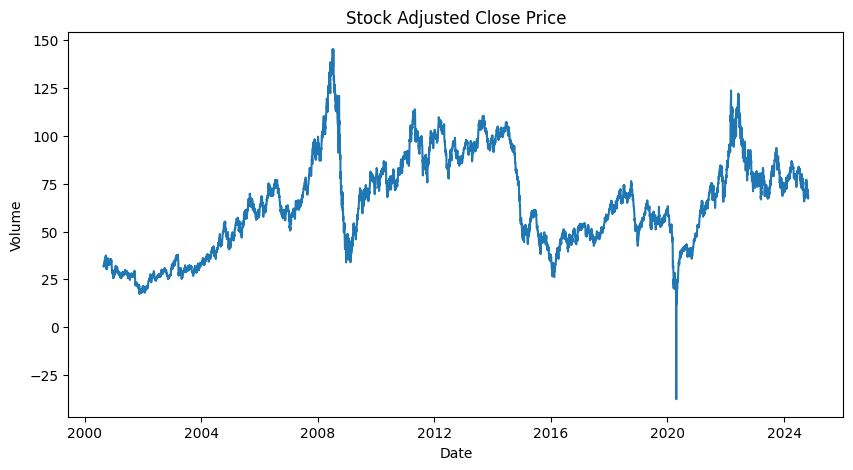

In [6]:
# ================================
# Step 4: Visualization
# ================================
# Closing Price Chart
plt.figure(figsize=(10,5))
plt.plot(data)
plt.title("Stock Adjusted Close Price")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

In [7]:
# ================================
# Step 5: Train Test Split
# ================================
train_size = int(len(data) * 0.8)

train = data[:train_size]
test = data[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 4858
Test size: 1215


In [8]:
# ================================
# Step 6: Build ARIMA Model
# ================================
model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

print(model_fit.summary())

c:\Users\Pandi selvam\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Pandi selvam\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Pandi selvam\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              Adj_Close   No. Observations:                 4858
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -8594.132
Date:                Mon, 09 Mar 2026   AIC                          17200.264
Time:                        11:25:02   BIC                          17239.193
Sample:                             0   HQIC                         17213.928
                               - 4858                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0540      0.007     -7.970      0.000      -0.067      -0.041
ar.L2         -0.0190      0.009     -2.007      0.045      -0.038      -0.000
ar.L3         -0.0004      0.010     -0.039      0.9

In [9]:
# ================================
# Step 7: Predict Test Data
# ================================
predictions = model_fit.forecast(steps=len(test))

c:\Users\Pandi selvam\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Pandi selvam\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [10]:
# ================================
# Step 8: Error Calculation
# ================================
mse = mean_squared_error(test, predictions)
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 22.777664705609787


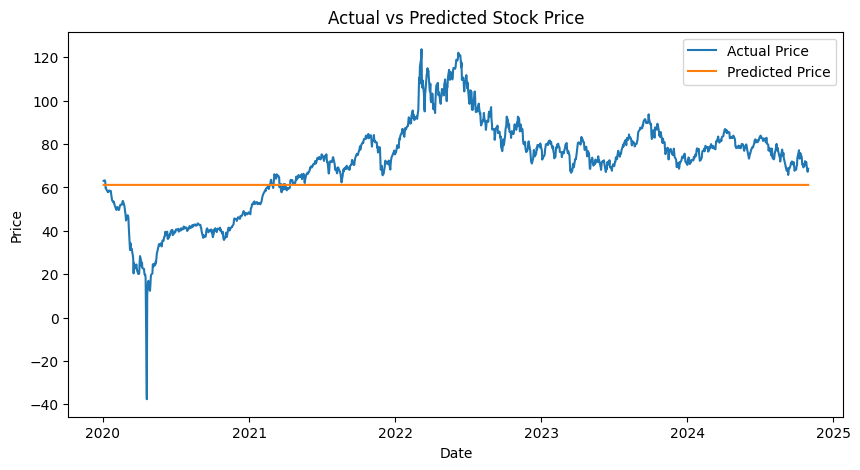

In [11]:
# ================================
# Step 9: Plot Actual vs Predicted
# ================================
plt.figure(figsize=(10,5))

plt.plot(test.index, test, label="Actual Price")
plt.plot(test.index, predictions, label="Predicted Price")

plt.title("Actual vs Predicted Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.show()

In [12]:
# ================================
# Step 10: Future Prediction
# ================================
future_days = 30

future_model = ARIMA(data, order=(5,1,0))
future_model_fit = future_model.fit()

future_forecast = future_model_fit.forecast(steps=future_days)

# Create future dates
future_dates = pd.date_range(start=data.index[-1], periods=future_days+1, freq="D")[1:]

future_df = pd.DataFrame({
    "Date": future_dates,
    "Predicted Price": future_forecast
})

print(future_df)

c:\Users\Pandi selvam\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Pandi selvam\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Pandi selvam\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                          Date  Predicted Price
6073 2024-10-31 00:00:00+00:00        68.544739
6074 2024-11-01 00:00:00+00:00        68.412076
6075 2024-11-02 00:00:00+00:00        68.486583
6076 2024-11-03 00:00:00+00:00        68.500095
6077 2024-11-04 00:00:00+00:00        68.468854
6078 2024-11-05 00:00:00+00:00        68.471072
6079 2024-11-06 00:00:00+00:00        68.475399
6080 2024-11-07 00:00:00+00:00        68.474049
6081 2024-11-08 00:00:00+00:00        68.473413
6082 2024-11-09 00:00:00+00:00        68.474117
6083 2024-11-10 00:00:00+00:00        68.474073
6084 2024-11-11 00:00:00+00:00        68.473959
6085 2024-11-12 00:00:00+00:00        68.473982
6086 2024-11-13 00:00:00+00:00        68.474005
6087 2024-11-14 00:00:00+00:00        68.473989
6088 2024-11-15 00:00:00+00:00        68.473989
6089 2024-11-16 00:00:00+00:00        68.473992
6090 2024-11-17 00:00:00+00:00        68.473992
6091 2024-11-18 00:00:00+00:00        68.473991
6092 2024-11-19 00:00:00+00:00        68

c:\Users\Pandi selvam\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Pandi selvam\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


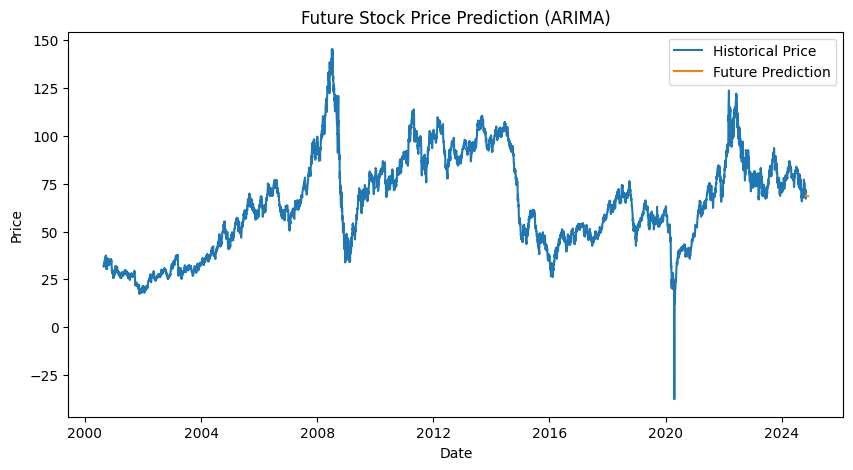

In [13]:
# ================================
# Step 11: Future Forecast Chart
# ================================
plt.figure(figsize=(10,5))

plt.plot(data.index, data, label="Historical Price")
plt.plot(future_dates, future_forecast, label="Future Prediction")

plt.title("Future Stock Price Prediction (ARIMA)")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.show()

c:\Users\Pandi selvam\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Pandi selvam\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Pandi selvam\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Model Training Completed

Enter today's stock details


Predicted Next Stock Price: 68.54473921318441


c:\Users\Pandi selvam\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Pandi selvam\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


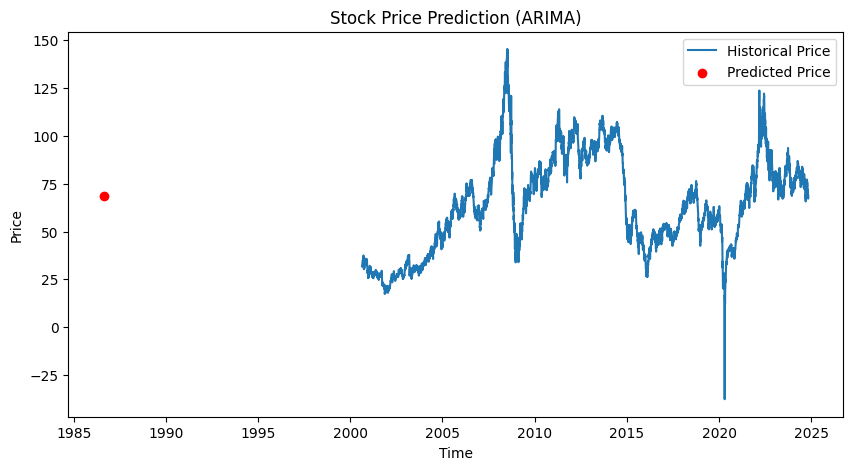

In [17]:
# ===============================
# Step 1: Import Libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# ===============================
# Step 2: Load Dataset
# ===============================
df = pd.read_csv(r"D:\Gradtwin\Stock Price Prediction\Oil_Data_Cleaned.csv")

# Convert date column
df["Date"] = pd.to_datetime(df["Date"])

# Set index
df.set_index("Date", inplace=True)

# Use Adjusted Close for ARIMA
data = df["Adj_Close"]

# ===============================
# Step 3: Train ARIMA Model
# ===============================
model = ARIMA(data, order=(5,1,0))
model_fit = model.fit()

print("Model Training Completed")

# ===============================
# Step 4: User Input
# ===============================
print("\nEnter today's stock details\n")

open_price = float(input("Enter Open Price: "))
high_price = float(input("Enter High Price: "))
low_price = float(input("Enter Low Price: "))
volume = float(input("Enter Volume: "))

# ===============================
# Step 5: Predict Next Price
# ===============================
prediction = model_fit.forecast(steps=1)

predicted_price = prediction.iloc[0]

print("\nPredicted Next Stock Price:", predicted_price)

# ===============================
# Step 6: Visualization
# ===============================
plt.figure(figsize=(10,5))

plt.plot(data, label="Historical Price")

plt.scatter(len(data), predicted_price, color="red", label="Predicted Price")

plt.title("Stock Price Prediction (ARIMA)")
plt.xlabel("Time")
plt.ylabel("Price")

plt.legend()
plt.show()

Model Training Completed

Model Equation:
Adj_Close = (-0.6630968367785208*Open) + (0.7863988731870444*High) + (0.8787732686963632*Low) + (-2.3781718594406698e-08*Volume) + 0.021124245979251555

Enter today's stock details


Predicted Stock Price: 64.00502232899919


c:\Users\Pandi selvam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


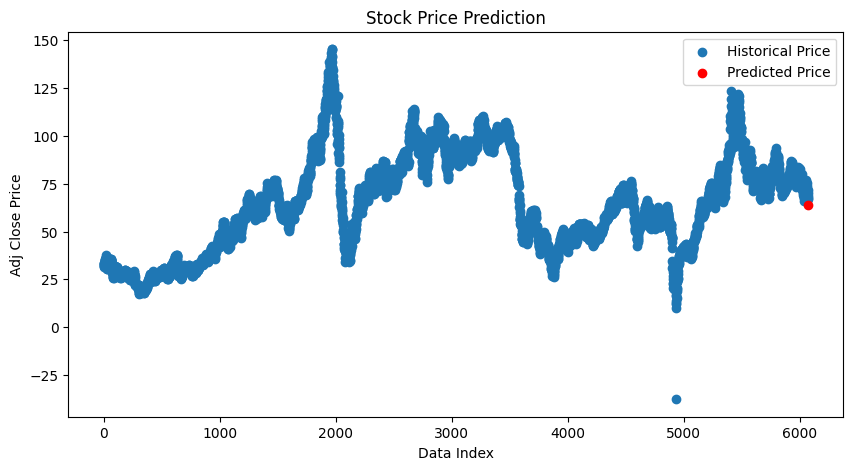

In [19]:
# ===============================
# Step 1: Import Libraries
# ===============================
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# ===============================
# Step 2: Load Dataset
# ===============================
df = pd.read_csv(r"D:\Gradtwin\Stock Price Prediction\Oil_Data_Cleaned.csv")

# ===============================
# Step 3: Prepare Features
# ===============================
X = df[["Open", "High", "Low", "Volume"]]
y = df["Adj_Close"]

# ===============================
# Step 4: Train Model
# ===============================
model = LinearRegression()
model.fit(X, y)

print("Model Training Completed")

# ===============================
# Step 5: Show Model Weights
# ===============================
w1, w2, w3, w4 = model.coef_
bias = model.intercept_

print("\nModel Equation:")
print(f"Adj_Close = ({w1}*Open) + ({w2}*High) + ({w3}*Low) + ({w4}*Volume) + {bias}")

# ===============================
# Step 6: User Input
# ===============================
print("\nEnter today's stock details\n")

open_price = float(input("Enter Open Price: "))
high_price = float(input("Enter High Price: "))
low_price = float(input("Enter Low Price: "))
volume = float(input("Enter Volume: "))

# ===============================
# Step 7: Prediction
# ===============================
input_data = [[open_price, high_price, low_price, volume]]

predicted_price = model.predict(input_data)

print("\nPredicted Stock Price:", predicted_price[0])

# ===============================
# Step 8: Visualization
# ===============================
plt.figure(figsize=(10,5))

plt.scatter(df.index, y, label="Historical Price")

plt.scatter(len(df), predicted_price[0], color="red", label="Predicted Price")

plt.title("Stock Price Prediction")
plt.xlabel("Data Index")
plt.ylabel("Adj Close Price")

plt.legend()
plt.show()

In [20]:
# ===============================
# Step 1: Import Libraries
# ===============================
import pandas as pd
from sklearn.linear_model import LinearRegression

# ===============================
# Step 2: Load CSV File
# ===============================
file_path = r"D:\Gradtwin\Stock Price Prediction\Oil_Data_Cleaned.csv"

df = pd.read_csv(file_path)

print("CSV File Loaded Successfully\n")

# ===============================
# Step 3: Select Features
# ===============================
X = df[["Open", "High", "Low", "Volume"]]

# Target column
y = df["Adj_Close"]

# ===============================
# Step 4: Train Model
# ===============================
model = LinearRegression()
model.fit(X, y)

print("Model Training Completed\n")

# ===============================
# Step 5: Predict All Rows
# ===============================
predictions = model.predict(X)

# Add predicted column
df["Predicted_Price"] = predictions

print("Prediction Completed\n")

# ===============================
# Step 6: Save New CSV File
# ===============================
output_path = r"D:\Gradtwin\Stock Price Prediction\Predicted_Stock_Data.csv"

df.to_csv(output_path, index=False)

print("Predicted CSV File Saved Successfully")
print("Location:", output_path)

# ===============================
# Step 7: Show First Results
# ===============================
print("\nFirst 10 Predicted Rows\n")

print(df[["Open","High","Low","Volume","Adj_Close","Predicted_Price"]].head(10))

CSV File Loaded Successfully

Model Training Completed

Prediction Completed

Predicted CSV File Saved Successfully
Location: D:\Gradtwin\Stock Price Prediction\Predicted_Stock_Data.csv

First 10 Predicted Rows

        Open       High        Low  Volume  Adj_Close  Predicted_Price
0  31.950001  32.799999  31.950001   79385  32.049999        32.703981
1  31.900000  32.240002  31.400000   72978  31.629999        31.813581
2  31.700001  32.099998  31.320000   44601  32.049999        31.766474
3  32.040001  32.919998  31.860001   46770  32.869999        32.660355
4  32.820000  33.029999  32.560001   49131  32.720001        32.844731
5  32.750000  33.400002  32.099998   79214  33.400002        32.777163
6  33.250000  33.700001  32.970001   56895  33.099998        33.446600
7  33.049999  33.450001  32.750000   45869  33.380001        33.189551
8  33.950001  33.990002  33.419998   55722  33.799999        33.605961
9  33.990002  34.950001  33.830002   74692  34.950001        34.694228
